# CRAI - Car Registration Artificial Inteligence

This notebook presents the development of a deep learning–based object detection system focused on vehicle analysis using computer vision techniques. The primary goal of this work is to build a robust **vehicle detection model** capable of identifying cars in images or video streams by predicting accurate bounding boxes. This model represents the first stage of a larger Automatic Number Plate Recognition (ANPR) pipeline and is designed to operate on both static images and real-time webcam input.

The methodology followed in this notebook adheres to best practices commonly used in modern deep learning workflows, including dataset exploration, preprocessing, data augmentation, transfer learning, model training, evaluation, and inference. The resulting vehicle detector will later be used as an upstream component to localize regions of interest (vehicles), enabling a second, more specialized model to focus exclusively on **license plate detection**. By separating the problem into two distinct detection tasks, the overall system becomes more accurate, scalable, and easier to maintain and improve over time.

## 1. Install dependecies

The first thing you need to do is to install all the required dependencies.

In [56]:
# Disable warnings by executing this cell
import warnings
warnings.filterwarnings("ignore")

In [57]:
import os
from glob import glob

### Tensorflow

Tensorflow is the core framework that translates the abstract ideas of Artificial Intelligence into a functional, high-performance program capable of performing complex vision tasks.

In [58]:
%pip install tensorflow==2.20.0
!python3 -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"
import tensorflow as tf

Note: you may need to restart the kernel to use updated packages.
2025-12-16 10:31:25.297067: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-16 10:31:25.393185: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-16 10:31:27.506423: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
[PhysicalDevic

### Pandas

Pandas is a powerful data manipulation library used for organizing, analyzing, and transforming datasets. In this project, it helps manage image paths, labels, and annotations in tabular format, making it easier to preprocess and inspect the dataset before training.

In [59]:
%pip install pandas==2.3.3
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


### Numpy

Numpy is the fundamental library for numerical computing in Python. It provides efficient multi-dimensional array operations, mathematical functions, and is essential for image processing and deep learning. In this project, it handles image data as arrays, performs coordinate transformations, and supports all numerical operations needed for training the model.

In [60]:
%pip install numpy==2.2.6
import numpy as np

Note: you may need to restart the kernel to use updated packages.


### Opencv

OpenCV (Open Source Computer Vision Library) is a highly optimized library for real-time computer vision and image processing. It provides essential tools for reading, writing, and manipulating images, as well as advanced operations like object detection, feature extraction, and geometric transformations. In this project, OpenCV is used for loading images, drawing bounding boxes, and visualizing detection results.

In [61]:
%pip install opencv-python==4.12.0.88
import cv2

Note: you may need to restart the kernel to use updated packages.


### Matplotlib

In [62]:
%pip install matplotlib==3.10.8
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Note: you may need to restart the kernel to use updated packages.


### Extra dependencies

In [63]:
%pip install tqdm==2.2.3
from tqdm import tqdm

Note: you may need to restart the kernel to use updated packages.


## 2. Import datasets

The UA-DETRAC dataset is to big (around 10 GB), so it can be loaded 

In [64]:
# Define basics constants
DATASET_DIR = r"/mnt/c/Users/iibai/Desktop/UA_DETRAC"
TRAIN_IMAGES_DIR = os.path.join(DATASET_DIR, "images", "train")
TRAIN_LABELS_DIR = os.path.join(DATASET_DIR, "labels", "train")
VAL_IMAGES_DIR   = os.path.join(DATASET_DIR, "images", "val")
VAL_LABELS_DIR = os.path.join(DATASET_DIR, "labels", "val")
IMG_SIZE_OBJECTIVE = (180, 320) # (height, width) Real img -> (540, 960), /3, Objective img -> (180, 320)
BATCH_SIZE = 16
EPOCHS = 50

In [65]:
print(os.path.exists(DATASET_DIR))
print(os.path.exists(TRAIN_IMAGES_DIR))
print(os.path.exists(TRAIN_LABELS_DIR))
print(os.path.exists(VAL_IMAGES_DIR))
print(os.path.exists(VAL_LABELS_DIR))

# Check if all paths exist before continuing
if not all([
    os.path.exists(DATASET_DIR),
    os.path.exists(TRAIN_IMAGES_DIR),
    os.path.exists(TRAIN_LABELS_DIR),
    os.path.exists(VAL_IMAGES_DIR),
    os.path.exists(VAL_LABELS_DIR)
]):
    raise FileNotFoundError(
        "❌ ERROR: One or more dataset paths do not exist. "
        "Please verify the DATASET_DIR path and ensure the dataset is properly downloaded and extracted."
    )
    
print("✅ All dataset paths verified successfully!")

True
True
True
True
True
✅ All dataset paths verified successfully!


### 1. Dataset Indexation

In [66]:
def index_dataset(images_dir: str, labels_dir: str) -> list[tuple[str, str]]:
    samples = []
    image_paths = []
    
    image_paths.extend(glob(os.path.join(images_dir, "*.jpg")))
        
    image_paths.sort()

    print(f"Found {len(image_paths)} images in {images_dir}")

    for img_path in tqdm(image_paths, desc="Indexing Dataset"):
        filename = os.path.splitext(os.path.basename(img_path))[0]
        
        label_path = os.path.join(labels_dir, filename + ".txt")

        if os.path.exists(label_path):
            samples.append((img_path, label_path))
        # Eliminamos el [WARNING] si no encontramos la etiqueta, ya que tqdm lo manejará
        # y no queremos inundar la consola, a menos que sea estrictamente necesario.
        # else: 
        #    print(f"[WARNING] Label not found for {img_path}")


    print(f"Total samples indexed: {len(samples)}")
    return samples

In [67]:
train_samples = index_dataset(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)
val_samples   = index_dataset(VAL_IMAGES_DIR, VAL_LABELS_DIR)

print(f"Train samples: {len(train_samples)}")
print(f"Validation samples: {len(val_samples)}")
print(f"Total samples: {len(train_samples) + len(val_samples)}")

Indexing Dataset:   0%|          | 38/83791 [00:00<03:42, 375.83it/s]

Found 83791 images in /mnt/c/Users/iibai/Desktop/UA_DETRAC/images/train


Total samples indexed: 82085


Indexing Dataset:   0%|          | 29/56340 [00:00<03:14, 288.87it/s]

Found 56340 images in /mnt/c/Users/iibai/Desktop/UA_DETRAC/images/val


Total samples indexed: 56167
Train samples: 82085
Validation samples: 56167
Total samples: 138252


### 2. Sample Inspection

Cargar manualmente algunas muestras del dataset (imagen + anotaciones)
y verificarlas visualmente antes de entrenar ningún modelo.

### 3. Standard Loading Function

Es la función estándar y definitiva que se encargará de:

- Cargar imágenes + labels desde disco
- Preprocesarlas
- Devolverlas en un formato que TensorFlow/Keras pueda entrenar eficientemente

Esta función define:
- El formato de entrada del modelo
- El formato de las etiquetas
- El tamaño de imagen
- La normalización
- La consistencia del dataset

Si esta función está mal:
- El modelo no converge
- Los resultados no son reproducibles
- Cambiar de modelo es imposible

In [68]:
def load_image(image_path: str) -> tf.Tensor:
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE_OBJECTIVE)
    image = tf.cast(image, tf.float32) / 255.0
    return image

In [69]:
# https://docs.ultralytics.com/datasets/detect/#ultralytics-yolo-format
def load_yolo_label(label_path: str) -> tuple[np.ndarray, np.ndarray]:
    boxes = []
    classes = []

    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])

            boxes.append([x, y, w, h])
            classes.append(class_id)

    return np.array(boxes, dtype=np.float32), np.array(classes, dtype=np.int32)

In [70]:
def load_sample(image_path: str, label_path: str) -> tuple[tf.Tensor, dict[str, tf.Tensor]]:

    image = load_image(image_path)

    boxes, classes = load_yolo_label(label_path)

    boxes = tf.convert_to_tensor(boxes, dtype=tf.float32)
    classes = tf.convert_to_tensor(classes, dtype=tf.int32)

    targets = {
        "boxes": boxes,
        "classes": classes
    }

    return image, targets

In [71]:
img_path, lbl_path = train_samples[0]

image, targets = load_sample(img_path, lbl_path)

print("Image shape:", image.shape)
print("Boxes shape:", targets["boxes"].shape)
print("Classes:", targets["classes"])

Image shape: (180, 320, 3)
Boxes shape: (7, 4)
Classes: tf.Tensor([1 1 1 1 1 1 1], shape=(7,), dtype=int32)


### 4. Basic Preprocessing

### 5. Data Augmentation (TRAIN only)

Transformaciones aleatorias a las imágenes de entrenamiento para:
- Aumentar la variabilidad del dataset
- Reducir overfitting
- Mejorar generalización
- Simular condiciones reales (ángulos, iluminación, etc.)

👉 Importante: NO se crean nuevas imágenes en disco, se generan on-the-fly durante el entrenamiento.

In [72]:
def augment_image(image: tf.Tensor) -> tf.Tensor:
    # Random horizontal flip
    # image = tf.image.random_flip_left_right(image)
    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.1)
    # Random contrast
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

    return image

Estas augmentations no rompen las bounding boxes

Tú todavía NO estás usando las bounding boxes en el modelo, solo las cargas.
Por eso:
- Puedes aplicar augmentation solo a la imagen
- Más adelante, cuando entrenemos detección real, ajustaremos las boxes

Por ahora, este paso es conceptual y estructural.

Creamos una función que envuelve load_sample():

In [73]:
def load_and_augment(image_path: str, label_path: str) -> tuple[tf.Tensor, dict[str, tf.Tensor]]:
    image, targets = load_sample(image_path, label_path)
    image = augment_image(image)
    return image, targets

Qué ganas con este paso
- El modelo ve variaciones realistas
- Mejor generalización
- Pipeline modular y profesional
- Fácil activar/desactivar augmentation

### 6. Dataset Pipeline

Construcción de un tf.data.Dataset que:
- Lee rutas de imágenes y labels
- Aplica loading + preprocessing
- Aplica data augmentation (solo TRAIN)
- Agrupa en batches
- Optimiza rendimiento (prefetch)

Esto es lo que Keras consume durante model.fit().

In [74]:
# Preparar listas de paths para imágenes y etiquetas
train_image_paths = [s[0] for s in train_samples]
train_label_paths = [s[1] for s in train_samples]

val_image_paths = [s[0] for s in val_samples]
val_label_paths = [s[1] for s in val_samples]

# Crear Dataset base
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_image_paths, train_label_paths)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, val_label_paths)
)

# Mapear loading + augmentation
## TRAIN
def tf_load_and_augment(img_path, lbl_path):
    def wrapper(img_p, lbl_p):
        image, targets = load_and_augment(img_p.numpy().decode('utf-8'), lbl_p.numpy().decode('utf-8'))
        return image.numpy(), targets["boxes"], targets["classes"]
    
    image, boxes, classes = tf.py_function(
        func=wrapper,
        inp=[img_path, lbl_path],
        Tout=[tf.float32, tf.float32, tf.int32]
    )

    image.set_shape((IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3))
    boxes.set_shape([None, 4])
    classes.set_shape([None])
    
    targets = {"boxes": boxes, "classes": classes}
    return image, targets

## VAL
def tf_load(img_path, lbl_path):
    def wrapper(img_p, lbl_p):
        image, targets = load_sample(img_p.numpy().decode('utf-8'), lbl_p.numpy().decode('utf-8'))
        return image.numpy(), targets["boxes"], targets["classes"]
    
    image, boxes, classes = tf.py_function(
        func=wrapper,
        inp=[img_path, lbl_path],
        Tout=[tf.float32, tf.float32, tf.int32]
    )

    image.set_shape((IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3))
    boxes.set_shape([None, 4])
    classes.set_shape([None])
    
    targets = {"boxes": boxes, "classes": classes}
    return image, targets

# Shuffle, batch y prefetch
## TRAIN
train_ds = (
    train_ds
    .shuffle(buffer_size=1000)
    .map(tf_load_and_augment, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        BATCH_SIZE,
        padded_shapes=(
            (IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3),
            {
                "boxes": [None, 4],
                "classes": [None]
            }
        ),
        padding_values=(
            0.0,
            {
                "boxes": 0.0,
                "classes": -1
            }
        )
    )
    .prefetch(tf.data.AUTOTUNE)
)
## VAL
val_ds = (
    val_ds
    .map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        BATCH_SIZE,
        padded_shapes=(
            (IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3),
            {
                "boxes": [None, 4],
                "classes": [None]
            }
        ),
        padding_values=(
            0.0,
            {
                "boxes": 0.0,
                "classes": -1
            }
        )
    )
    .prefetch(tf.data.AUTOTUNE)
)
# Verificación final (OBLIGATORIA)
for images, targets in train_ds.take(1):
    print(images.shape)
    print(targets["boxes"].shape)
    print(targets["classes"].shape)

(16, 180, 320, 3)
(16, 15, 4)
(16, 15)


### 7. Batch Validation

Inspeccionar un batch completo del dataset para asegurarte de que:
- Las imágenes están correctamente redimensionadas y normalizadas
- Los bounding boxes corresponden a las imágenes
- Las clases son correctas
- No hay errores de padding

Es una verificación visual y de shapes antes de entrenar.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10406536..1.0537704].


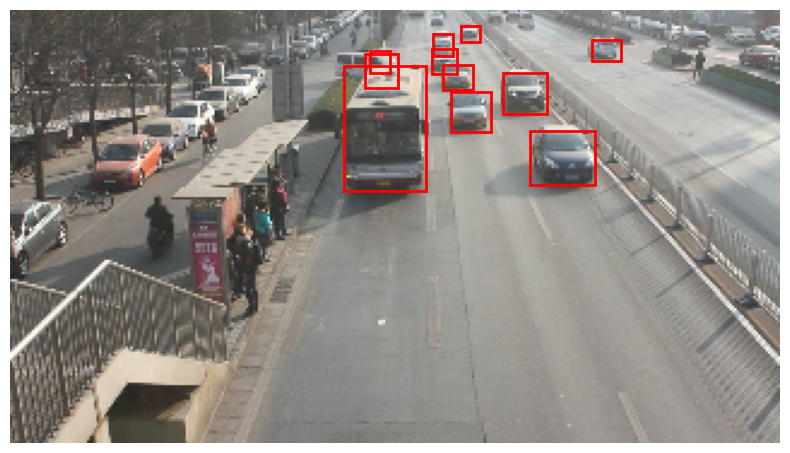

In [75]:
# Tomar un batch
for images, targets in train_ds.take(1):
    batch_images = images.numpy()
    batch_boxes = targets["boxes"].numpy()
    batch_classes = targets["classes"].numpy()

# Seleccionar la primera imagen del batch
image = batch_images[0]
boxes = batch_boxes[0]
classes = batch_classes[0]

# Crear figura
fig, ax = plt.subplots(1, figsize=(8,6))
ax.imshow(image)

# Dibujar las bounding boxes
for i in range(len(boxes)):
    if classes[i] == -1:
        continue  # padded box
    x_center, y_center, w, h = boxes[i]
    
    # Convertir de YOLO normalized a coordenadas de la imagen
    img_h, img_w = IMG_SIZE_OBJECTIVE
    x = (x_center - w/2) * img_w
    y = (y_center - h/2) * img_h
    width = w * img_w
    height = h * img_h

    rect = patches.Rectangle(
        (x, y), width, height,
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)

ax.axis('off')
plt.tight_layout()
plt.show()
